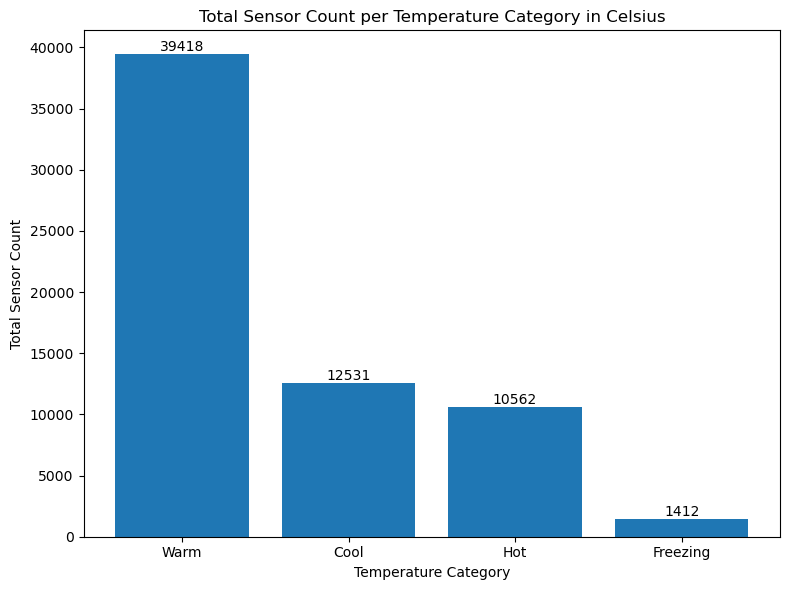

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GlobalWeatherRepository.csv")

# Exploratory Data Analysis (EDA) - Bar Chart Total Sensor Count per Temperature Category in Celsius
# Dataset
df['temperature_category'] = pd.cut(
    df['temperature_celsius'],
    bins=[-50, 0, 15, 30, 50],
    labels=['Freezing', 'Cool', 'Warm', 'Hot']
)
# Count each temperature category
temp_counts = df['temperature_category'].value_counts().sort_values(ascending=False)

# Bar Chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(temp_counts.index, temp_counts.values)
# Plot the Label
ax.bar_label(bars, labels=temp_counts.values, label_type='edge')
ax.set_title('Total Sensor Count per Temperature Category in Celsius')
ax.set_xlabel('Temperature Category')
ax.set_ylabel('Total Sensor Count')
plt.tight_layout()
plt.show()

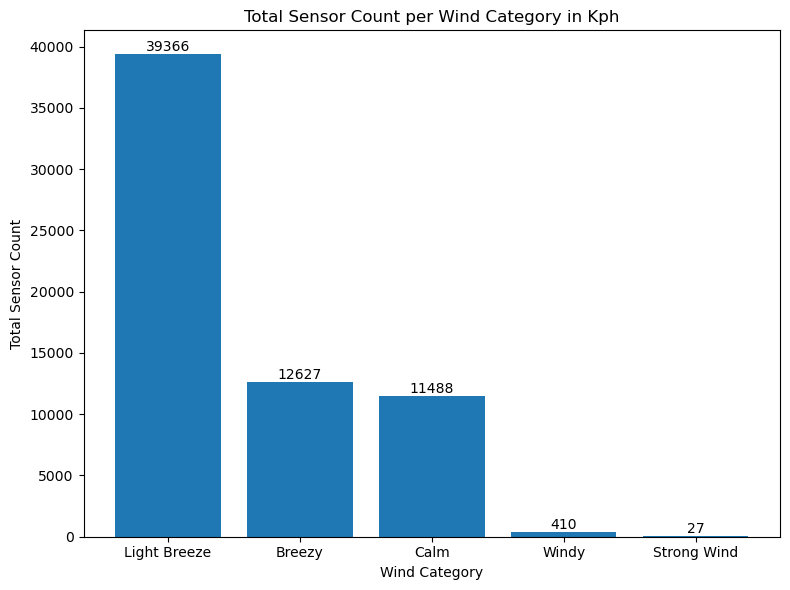

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GlobalWeatherRepository.csv")

# Exploratory Data Analysis (EDA) - Bar Chart Total Sensor Count per Wind Category in Kph
# Dataset
df['wind_category'] = pd.cut(
    df['wind_kph'],
    bins=[-1, 5, 20, 40, 60, 100],
    labels=['Calm', 'Light Breeze', 'Breezy', 'Windy', 'Strong Wind']
)
# Count each temperature category
temp_counts = df['wind_category'].value_counts().sort_values(ascending=False)

# Bar Chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(temp_counts.index, temp_counts.values)
# Plot the Label
ax.bar_label(bars, labels=temp_counts.values, label_type='edge')
ax.set_title('Total Sensor Count per Wind Category in Kph')
ax.set_xlabel('Wind Category')
ax.set_ylabel('Total Sensor Count')
plt.tight_layout()
plt.show()

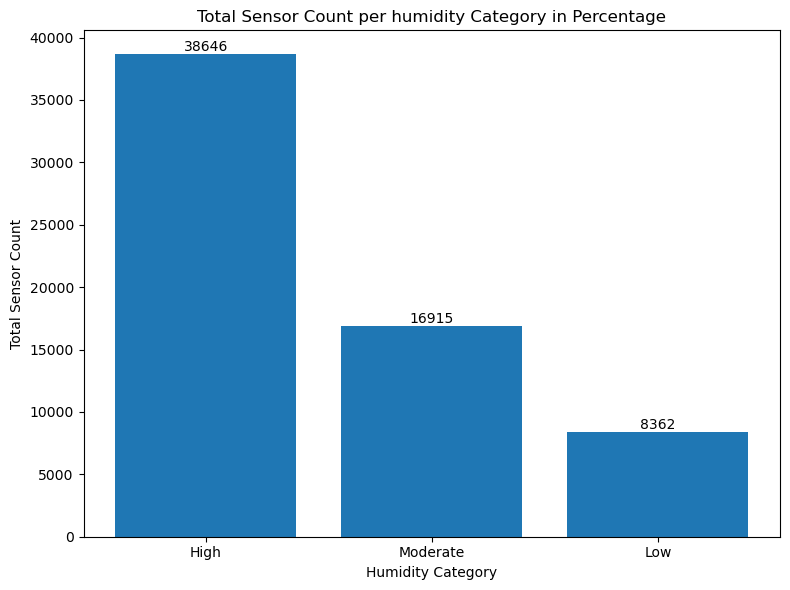

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GlobalWeatherRepository.csv")

# Exploratory Data Analysis (EDA) - Bar Chart Total Sensor Count per Humidity Category in Percentage
# Dataset
df['humidity_category'] = pd.cut(
    df['humidity'],
    bins=[0, 30, 60, 100],
    labels=['Low', 'Moderate', 'High']
)
# Count each temperature category
temp_counts = df['humidity_category'].value_counts().sort_values(ascending=False)

# Bar Chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(temp_counts.index, temp_counts.values)
# Plot the Label
ax.bar_label(bars, labels=temp_counts.values, label_type='edge')
ax.set_title('Total Sensor Count per humidity Category in Percentage')
ax.set_xlabel('Humidity Category')
ax.set_ylabel('Total Sensor Count')
plt.tight_layout()
plt.show()

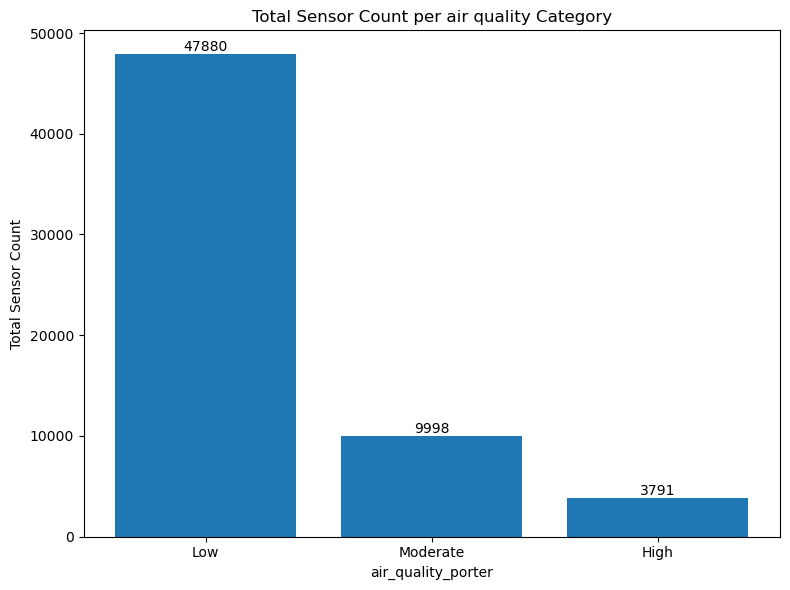

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GlobalWeatherRepository.csv")

# Exploratory Data Analysis (EDA) - Bar Chart Total Sensor Count per Humidity Category
# Dataset
df['air_quality_porter'] = pd.cut(
    df['air_quality_PM2.5'],
    bins=[0, 30, 60, 100],
    labels=['Low', 'Moderate', 'High']
)
# Count each temperature category
temp_counts = df['air_quality_porter'].value_counts().sort_index()

# Bar Chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(temp_counts.index, temp_counts.values)
# Plot the Label
ax.bar_label(bars, labels=temp_counts.values, label_type='edge')
ax.set_title('Total Sensor Count per air quality Category')
ax.set_xlabel('air_quality_porter')
ax.set_ylabel('Total Sensor Count')
plt.tight_layout()
plt.show()

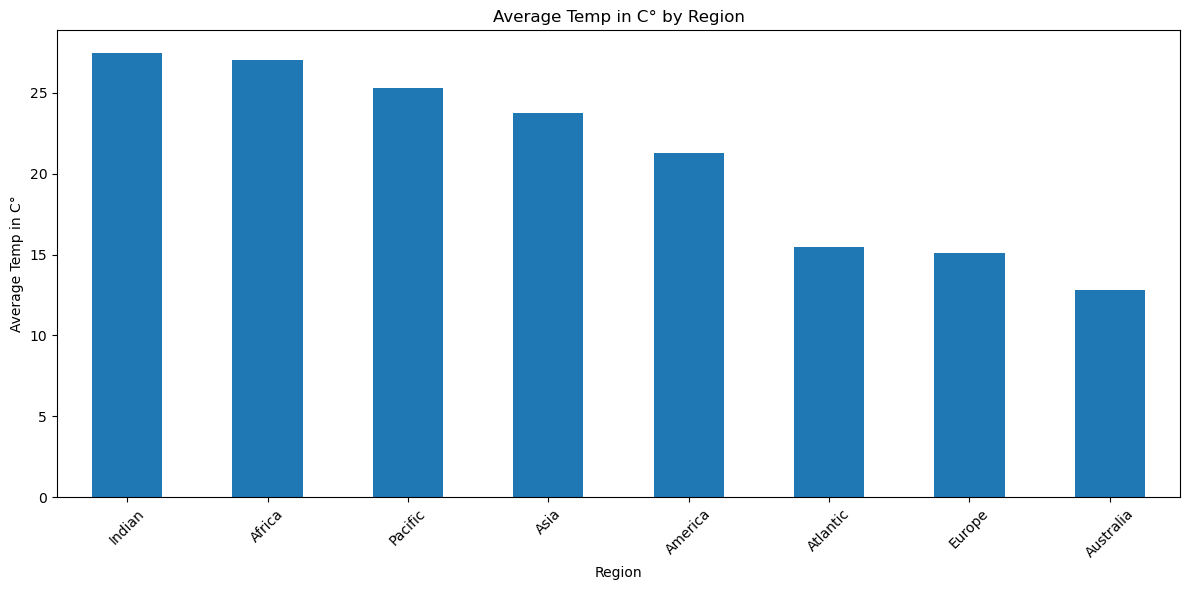

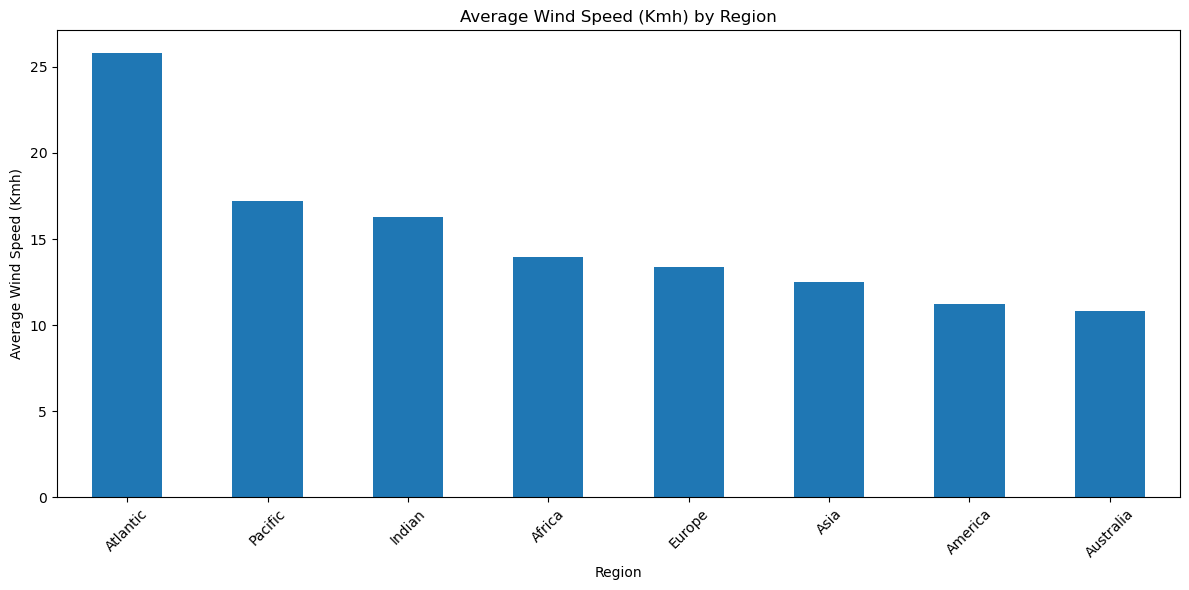

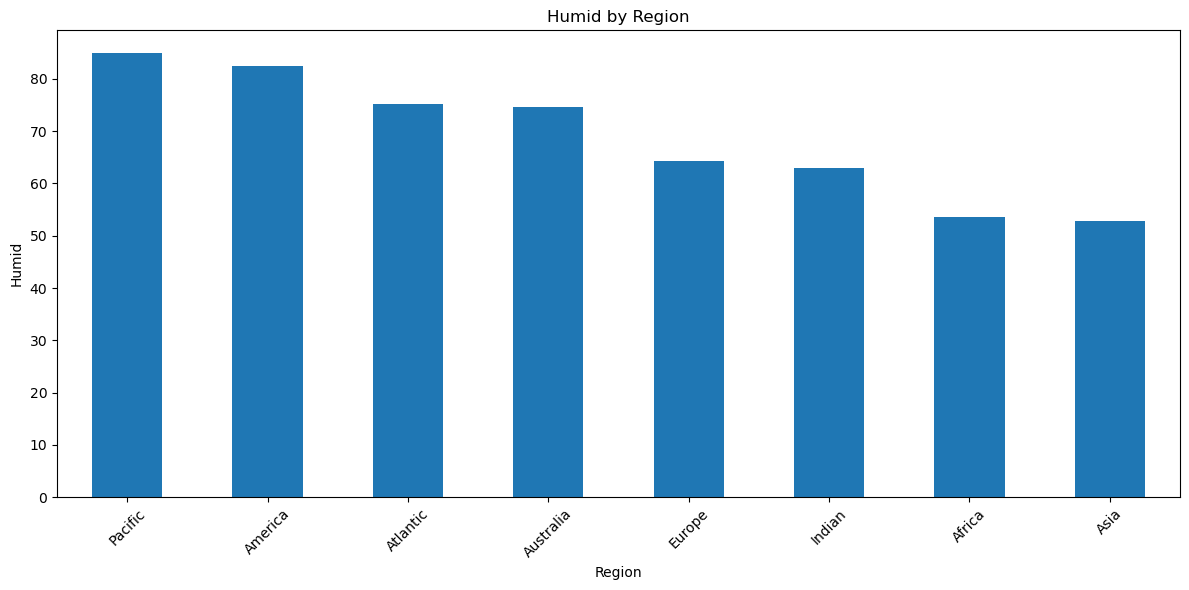

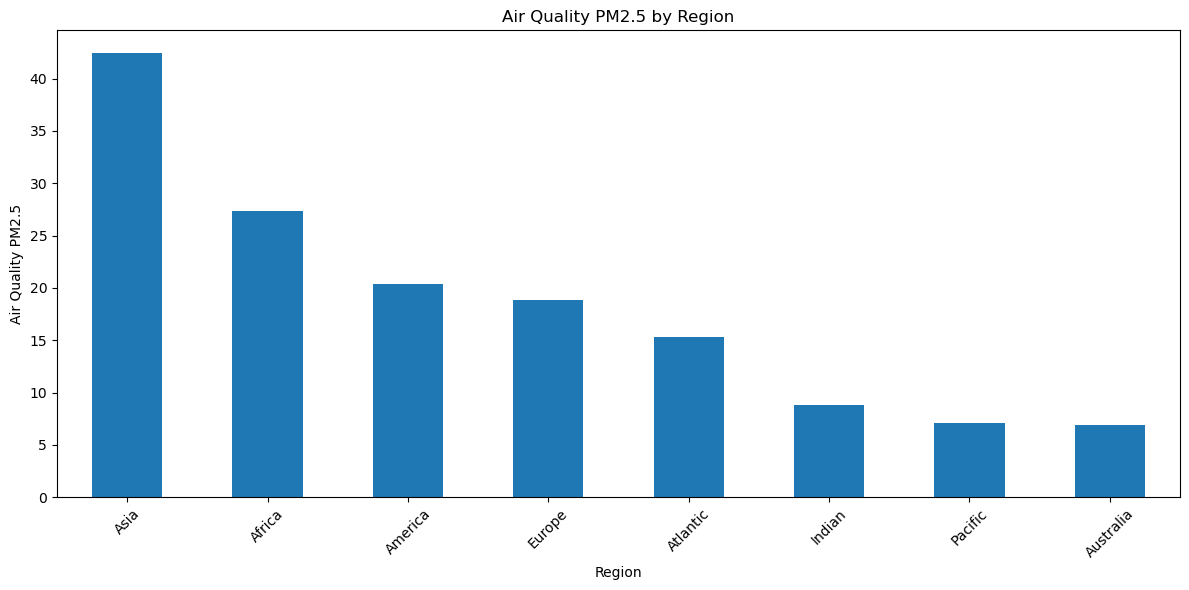

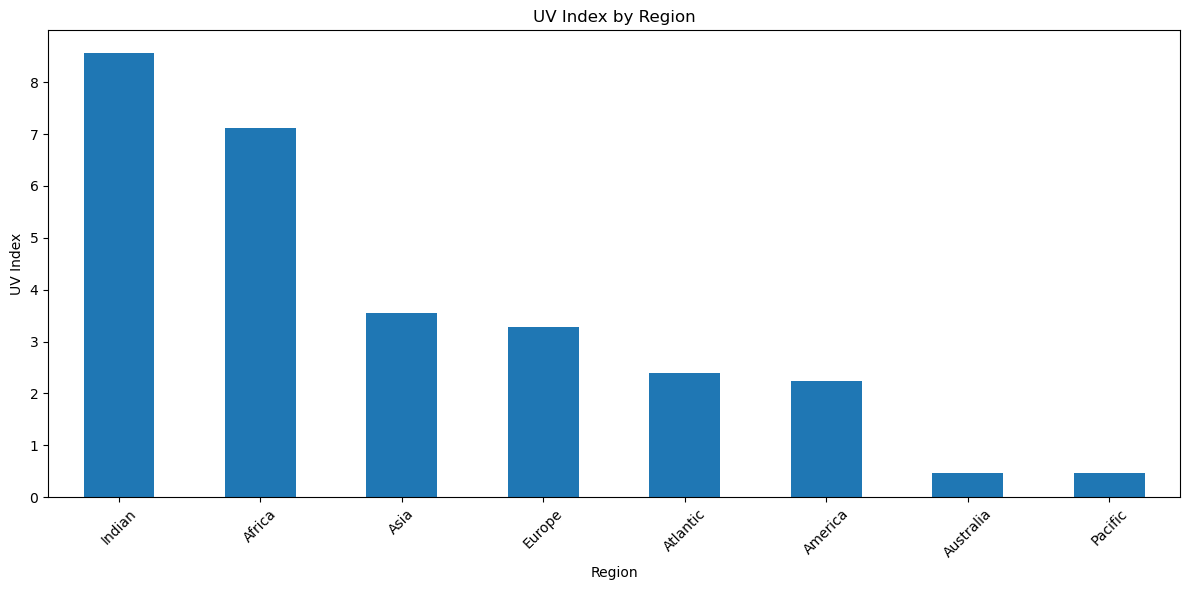

In [5]:
import pandas as pd
import statistics
import numpy as np
import matplotlib.pyplot as plt

# Exploratory Data Analysis (EDA) - Bar Chart Show Region Average Temp, Wind Speed, Humid, Air Quality, and UV Index
data = pd.read_csv("GlobalWeatherRepository.csv")

# Define Region from first string index after split "/"
data['region'] = data['timezone'].str.split('/').str[0]

# Group By Context and Average
region_data = data.groupby('region')[['temperature_celsius','wind_kph','humidity','air_quality_PM2.5','uv_index']].mean().round(2)
region_data = region_data.rename(columns={
    'temperature_celsius': 'Average Temp in C°',
    'wind_kph': 'Average Wind Speed (Kmh)',
    'humidity': 'Humid',
    'air_quality_PM2.5': 'Air Quality PM2.5',
    'uv_index': 'UV Index'
})

# Plot the Bar Chart
for col in region_data.columns:
    plt.figure(figsize=(12,6))
    region_data[col].sort_values(ascending=False).plot(kind='bar')
    plt.title(f'{col} by Region')
    plt.xlabel('Region')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

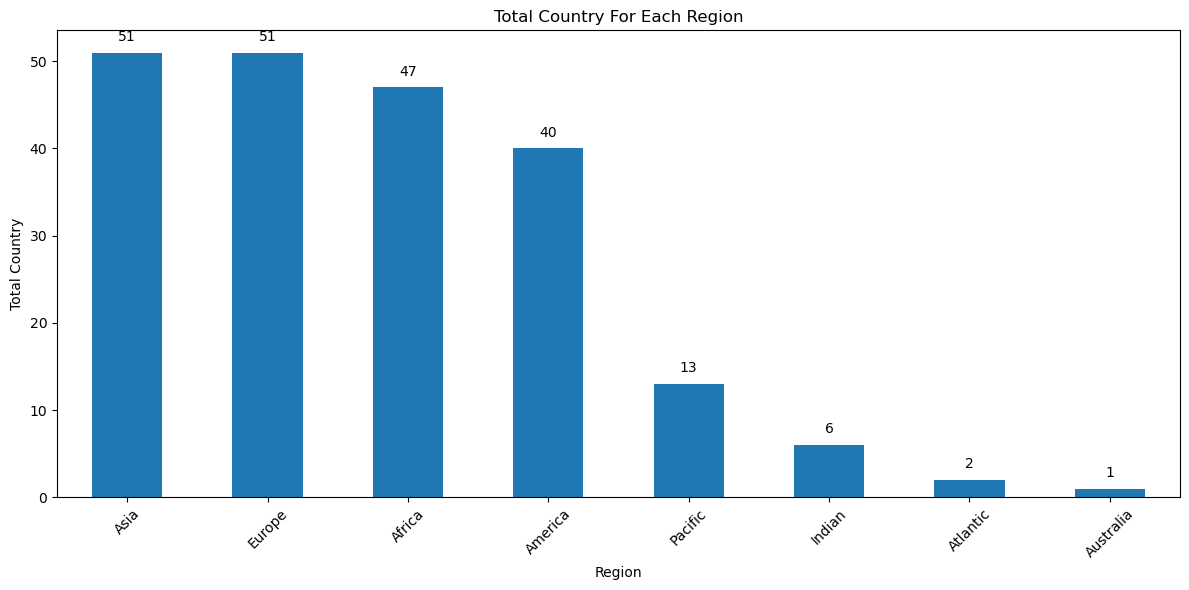

In [13]:
import pandas as pd
import statistics
import numpy as np
import matplotlib.pyplot as plt

# Exploratory Data Analysis (EDA) - Bar Chart Show Total Country For Each Region
data = pd.read_csv("GlobalWeatherRepository.csv")

# Define Region from first string index after split "/"
data['region'] = data['timezone'].str.split('/').str[0]

# Count unique countries per region
region_country_count = data.groupby('region')['country'].nunique().sort_values(ascending=False)

# Plot the Bar Chart
plt.figure(figsize=(12, 6))
region_country_count.plot(kind='bar')
# Add label
for i, value in enumerate(region_country_count):
    plt.text(i, value + 1, str(value), ha='center', va='bottom')
plt.title('Total Country For Each Region')
plt.xlabel('Region')
plt.ylabel('Total Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

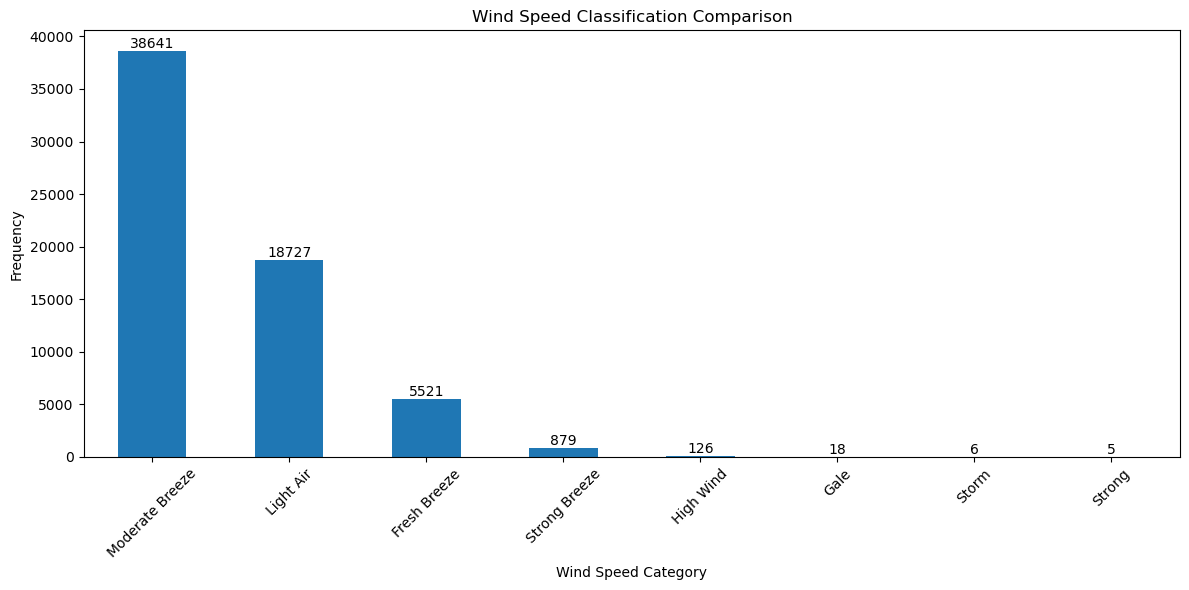

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("GlobalWeatherRepository.csv")

# Exploratory Data Analysis (EDA) - Bar Chart Wind Speed Classification Comparison (m/s)
def classification_wind_speed(val):
    mps = val * 0.27778

    if mps > 25:
        return "Storm"
    elif mps > 20:
        return "Strong"
    elif mps > 17:
        return "Gale"
    elif mps > 13:
        return "High Wind"
    elif mps > 10:
        return "Strong Breeze"
    elif mps > 7:
        return "Fresh Breeze"
    elif mps > 2:
        return "Moderate Breeze"
    else:
        return "Light Air"

df["Wind Speed Classification"] = df["wind_kph"].apply(classification_wind_speed)

# Dataset 
top_context = df["Wind Speed Classification"].value_counts().sort_values(ascending=False)

# Plot the Bar Chart
plt.figure(figsize=(12, 6))
top_context.plot(kind='bar')
# Add label
for i, value in enumerate(top_context):
    plt.text(i, value + 1, str(value), ha='center', va='bottom')
plt.title('Wind Speed Classification Comparison')
plt.xlabel('Wind Speed Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

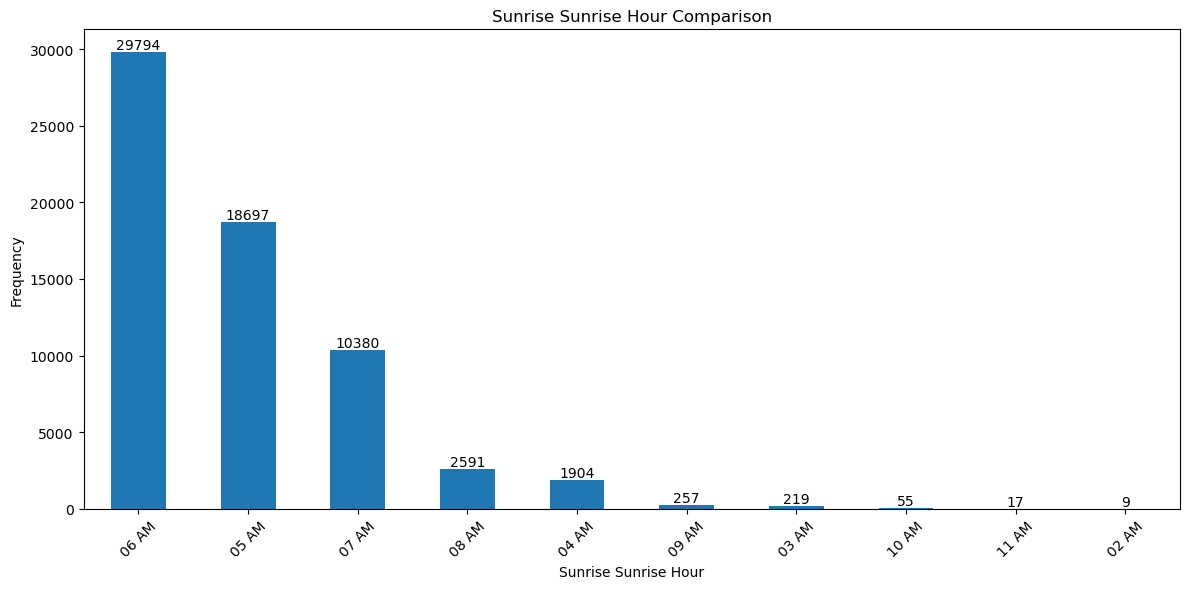

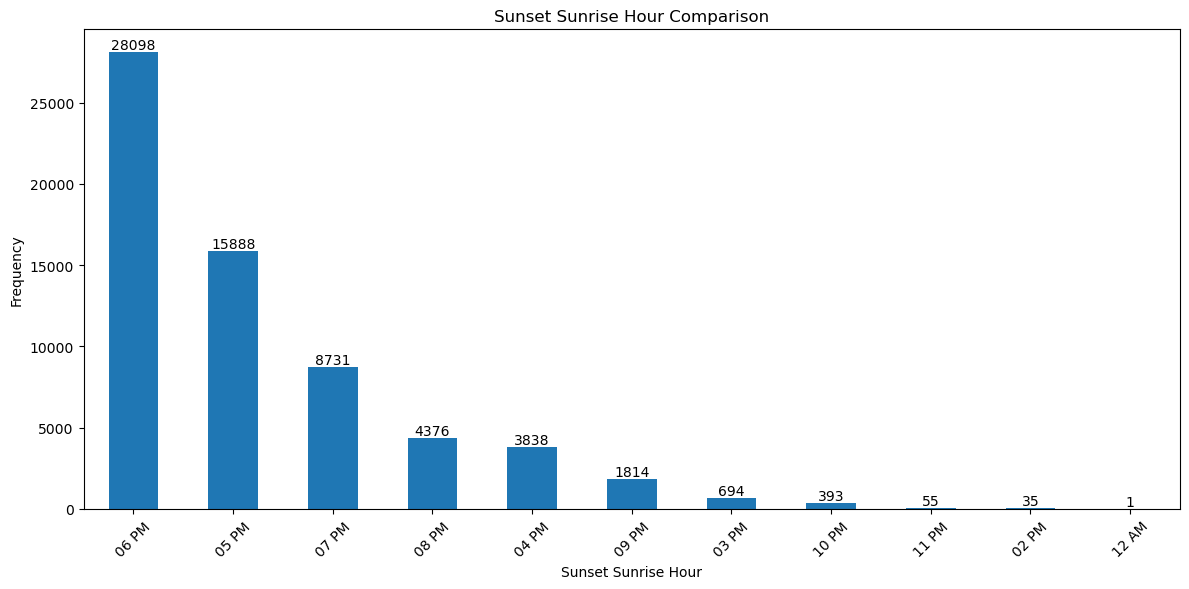

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
df = pd.read_csv("GlobalWeatherRepository.csv")

# Exploratory Data Analysis (EDA) - Pie Chart Sunrise, Sunset Hour Comparison
def get_hour(val):
    return f"{val[:2]} {val[-2:]}"

target_col = ['sunrise','sunset']

for dt in target_col:
    df[f"{dt.title()} Hour Comparison"] = df[dt].apply(get_hour)
    
    top_context = df[f"{dt.title()} Hour Comparison"].value_counts().sort_values(ascending=False)
    
    # Plot the Bar Chart
    plt.figure(figsize=(12, 6))
    top_context.plot(kind='bar')
    # Add label
    for i, value in enumerate(top_context):
        plt.text(i, value + 1, str(value), ha='center', va='bottom')
    plt.title(f"{dt.title()} Sunrise Hour Comparison")
    plt.xlabel(f"{dt.title()} Sunrise Hour")
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()